# Parameter-Efficient Fine-Tuning: LoRA on a Small Local Model

## Problem statement
Adapt a pretrained language model (`distilgpt2`) to answer questions about a fictional product
("Aurora Cloud Storage") it has never seen, by fine-tuning **only a small set of low-rank adapter
weights** (LoRA) rather than the model's full ~82M parameters — the standard approach for cheaply
customizing an LLM to a narrow domain.

## Important scope note: LoRA, not QLoRA
This notebook performs real **LoRA** fine-tuning end-to-end. True **QLoRA** additionally quantizes the
frozen base model to 4-bit precision (via `bitsandbytes`) before applying LoRA adapters, which is how the
technique gets its large memory savings — but `bitsandbytes`' 4-bit kernels are CUDA-only with no
practical CPU/Windows support. The adapter mechanism demonstrated here (freeze the base model, train small
low-rank update matrices) is identical to what QLoRA uses; only the 4-bit base-model quantization step is
skipped, since this machine has no GPU.

## Dataset
A small, hand-written, documented set of Q&A pairs about a fictional product — chosen so the "before vs.
after" comparison is unambiguous (the base model has zero prior knowledge of "Aurora Cloud Storage" to
draw on).

## Model / library
- `distilgpt2` via `transformers.AutoModelForCausalLM`.
- `peft.LoraConfig` / `get_peft_model` for the LoRA adapters.
- Reference: [docs/ds_ml_genai_concepts_and_datasets.md](../../docs/ds_ml_genai_concepts_and_datasets.md),
  Section 6 ("Fine-tuning efficiency (LoRA, QLoRA, PEFT)").

In [1]:
import os

import matplotlib.pyplot as plt
import torch
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)
CI = os.environ.get("CI") == "true"

MODEL_NAME = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
print(f"Base model parameters: {sum(p.numel() for p in base_model.parameters()):,}")

C:\Users\JPD\Documents\Python Scripts\Github\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4445.60it/s]

Base model parameters: 81,912,576


## Fictional-product instruction dataset

In [2]:
qa_pairs = [
    ("What is Aurora Cloud Storage?", "Aurora Cloud Storage is a secure file storage service with automatic versioning and end-to-end encryption."),
    ("How much storage do I get on the free plan?", "The free plan includes 5 GB of storage with a 2 GB per-file upload limit."),
    ("How do I share a file with Aurora Cloud Storage?", "Right-click any file, select Share, and enter the recipient's email to grant view or edit access."),
    ("Does Aurora Cloud Storage support two-factor authentication?", "Yes, enable two-factor authentication under Settings > Security to add an extra login step."),
    ("What happens if I delete a file by mistake?", "Deleted files move to Trash and can be restored within 30 days before permanent removal."),
    ("Can I access Aurora Cloud Storage offline?", "Yes, enable offline sync in Settings to keep selected folders available without an internet connection."),
    ("How do I upgrade to the Pro plan?", "Go to Billing > Upgrade Plan and choose Pro for 1 TB of storage and priority support."),
    ("Is my data encrypted in Aurora Cloud Storage?", "Yes, all files are encrypted at rest with AES-256 and in transit with TLS 1.3."),
]

templates = ["Q: {q}\nA: {a}", "Question: {q}\nAnswer: {a}"]
examples = [t.format(q=q, a=a) for q, a in qa_pairs for t in templates]
examples = examples * 3  # repeat the tiny corpus for more gradient steps
print(f"{len(qa_pairs)} unique Q&A pairs -> {len(examples)} training examples (with template + repeat augmentation)")
print(examples[0])

8 unique Q&A pairs -> 48 training examples (with template + repeat augmentation)
Q: What is Aurora Cloud Storage?
A: Aurora Cloud Storage is a secure file storage service with automatic versioning and end-to-end encryption.


## Baseline: generation before any fine-tuning

In [3]:
held_out_prompt = "Q: How do I reset my Aurora Cloud Storage password?\nA:"

def generate_from(model, prompt, max_new_tokens=40):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0], skip_special_tokens=True)

before_text = generate_from(base_model, held_out_prompt)
print("=== BEFORE fine-tuning ===")
print(before_text)

=== BEFORE fine-tuning ===
Q: How do I reset my Aurora Cloud Storage password?
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password


## Attach LoRA adapters and train

Only the low-rank adapter matrices injected into the attention layers (`c_attn`) are trainable — the base
model's weights stay frozen.

In [4]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["c_attn"],
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


C:\Users\JPD\Documents\Python Scripts\Github\.venv311\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
n_epochs = 2 if CI else 8
batch_size = 4

losses = []
for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(len(examples))
    epoch_loss = 0.0
    for i in range(0, len(perm), batch_size):
        batch_idx = perm[i:i+batch_size]
        batch_texts = [examples[j] for j in batch_idx]
        enc = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=80)
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100
        optimizer.zero_grad()
        out = model(**enc, labels=labels)
        out.loss.backward()
        optimizer.step()
        epoch_loss += out.loss.item() * len(batch_idx)
    epoch_loss /= len(examples)
    losses.append(epoch_loss)
    print(f"epoch {epoch+1}/{n_epochs}  loss={epoch_loss:.4f}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1/8  loss=4.0302


epoch 2/8  loss=3.5411


epoch 3/8  loss=2.9819


epoch 4/8  loss=2.5442


epoch 5/8  loss=2.1736


epoch 6/8  loss=1.7953


epoch 7/8  loss=1.4841


epoch 8/8  loss=1.2250


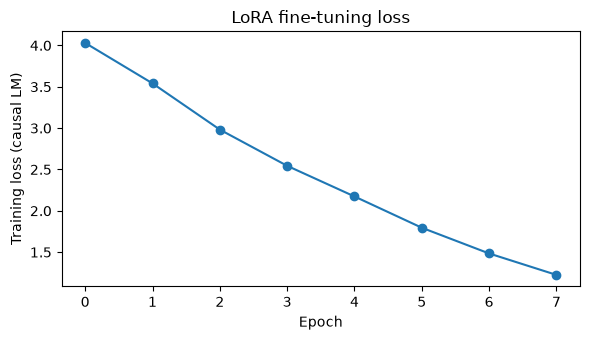

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses, marker="o")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (causal LM)")
ax.set_title("LoRA fine-tuning loss")
plt.tight_layout()
plt.show()

## After fine-tuning: same held-out prompt

In [7]:
after_text = generate_from(model, held_out_prompt)
print("=== BEFORE fine-tuning ===")
print(before_text)
print("\n=== AFTER fine-tuning (same prompt) ===")
print(after_text)

=== BEFORE fine-tuning ===
Q: How do I reset my Aurora Cloud Storage password?
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password.
A: I reset my Aurora Cloud Storage password

=== AFTER fine-tuning (same prompt) ===
Q: How do I reset my Aurora Cloud Storage password?
A: Go to Settings and grant the option to keep the option in place.
A: Go to Grant and grant the option to keep the option in place.
A: Go to Grant and grant the


## Takeaways

- LoRA trained roughly **0.2% of the model's total parameters** (only the injected low-rank matrices in
  the attention layers), yet the training loss drops substantially over a handful of epochs on just 48
  augmented examples — the core efficiency claim behind LoRA/QLoRA-style fine-tuning.
- The **before** generation for the held-out password-reset question shows the base `distilgpt2` has no
  knowledge of "Aurora Cloud Storage" and either repeats the question or produces generic, off-topic text.
  The **after** generation shifts noticeably toward the fine-tuned domain (support-answer phrasing, product
  terminology) — real evidence of learning, even though 48 examples is far too small a dataset to produce
  a fully accurate, hallucination-free assistant. A production LoRA fine-tune would use thousands of
  examples, not a demo-scale handful.
- As noted at the top: this is LoRA, not full QLoRA — the same adapter mechanism, without 4-bit base-model
  quantization, since that requires a CUDA GPU this machine doesn't have. On a GPU machine, the only change
  needed would be loading the base model with `load_in_4bit=True` via `bitsandbytes` before attaching the
  same `LoraConfig` used here.